# Lab 1

### Task Selection:
- Use the Ukrainian Emotion Recognition dataset

In [2]:
import os
from dotenv import load_dotenv

DATA_DIR = "data/raw/"

if not os.path.exists("data"):
    os.mkdir("data")

load_dotenv('.env')

if os.environ.get("HF_TOKEN"):
    print("Using Hugging Face token from .enve fil")
else:
    print("No Hugging Face token found in .env file")


Using Hugging Face token from .enve fil


In [3]:
%%bash
TOKEN_ARG=""
if [ -n "$HF_TOKEN" ]; then
    TOKEN_ARG="--token $HF_TOKEN"
fi

if [ ! -d "data/raw" ] || [ -z "$(ls -A data/raw 2>/dev/null)" ]; then
    hf download OlhaHavryliuk/UA-SER --repo-type dataset --local-dir data/raw $TOKEN_ARG
else
    echo "data/raw already exists and is not empty, skipping download."
fi


data/raw already exists and is not empty, skipping download.


### EDA and Metric Analysis:
- Perform Exploratory Data Analysis (EDA).

Audio shape: (29700,), Sample rate: 16000
filename                              s_001_1.wav
emotion                                       sad
duration_seconds                             1.86
text                Якщо в тебе щось не виходить,
speaker_id                                    166
split                                       train
sex                                        female
nwords                                          6
Name: 0, dtype: object
Audio duration: 1.86 seconds


/tmp/ipykernel_1283/727173058.py:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


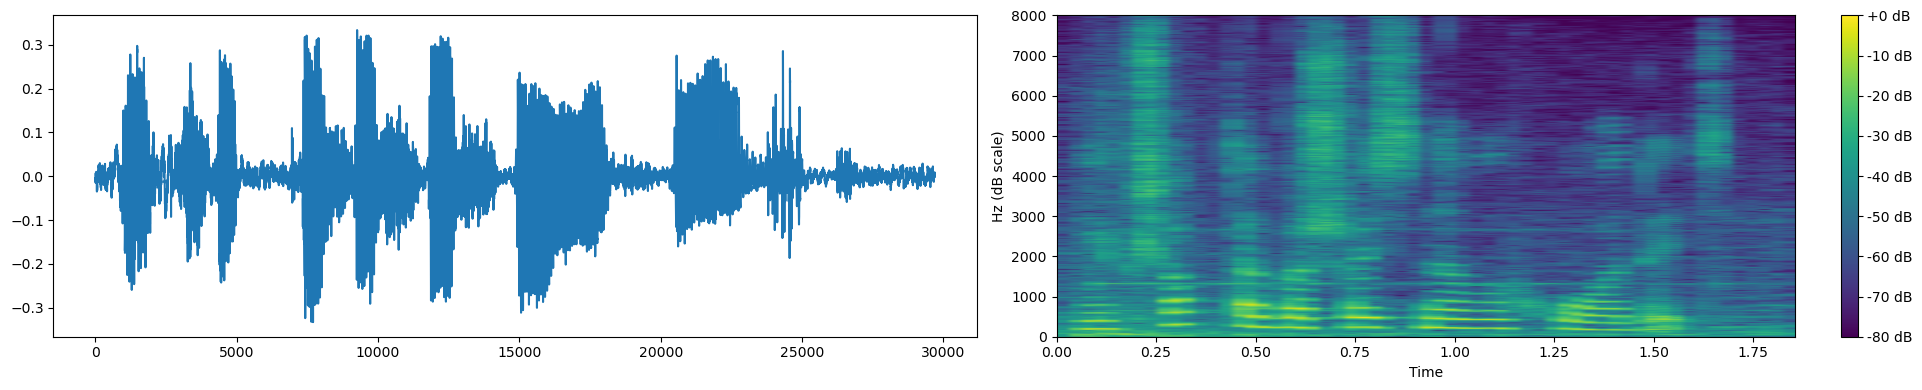

In [4]:

from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import librosa
import IPython.display as ipd
from matplotlib.ticker import MaxNLocator

SR = 16000
CLIPS_DIR = Path(DATA_DIR) / "clips"

df = pd.read_csv(Path(DATA_DIR) / "dataset.csv")
df["sex"] = df["filename"].apply(lambda x: 'female' if int(x.split(".")[0].split("_")[-1]) else 'male')
df["nwords"] = df["text"].apply(lambda x: len(x.split(' ')))

test = df[df["split"] == "train"]

SAMPLE = test.iloc[0]
SAMPLE_PATH = CLIPS_DIR / SAMPLE['filename']

y, sr = librosa.load(SAMPLE_PATH, sr=SR)

stfy_y = np.abs(librosa.stft(y))
stfy_y = librosa.amplitude_to_db(stfy_y, ref=np.max)

print(f"Audio shape: {y.shape}, Sample rate: {sr}")
print(SAMPLE)
print(f"Audio duration: {len(y) / sr:.2f} seconds")

fig, ax = plt.subplots(ncols=2, figsize=(20, 4))
ax[0].plot(y)

img = ax[1].imshow(stfy_y, aspect='auto', origin='lower', extent=[0, len(y)/sr, 0, sr/2])
ax[1].set_xlabel('Time')
ax[1].set_ylabel('Hz (dB scale)')
fig.colorbar(img, ax=ax[1], format='%+2.0f dB')

fig.tight_layout()
fig.show()

ipd.Audio(SAMPLE_PATH)


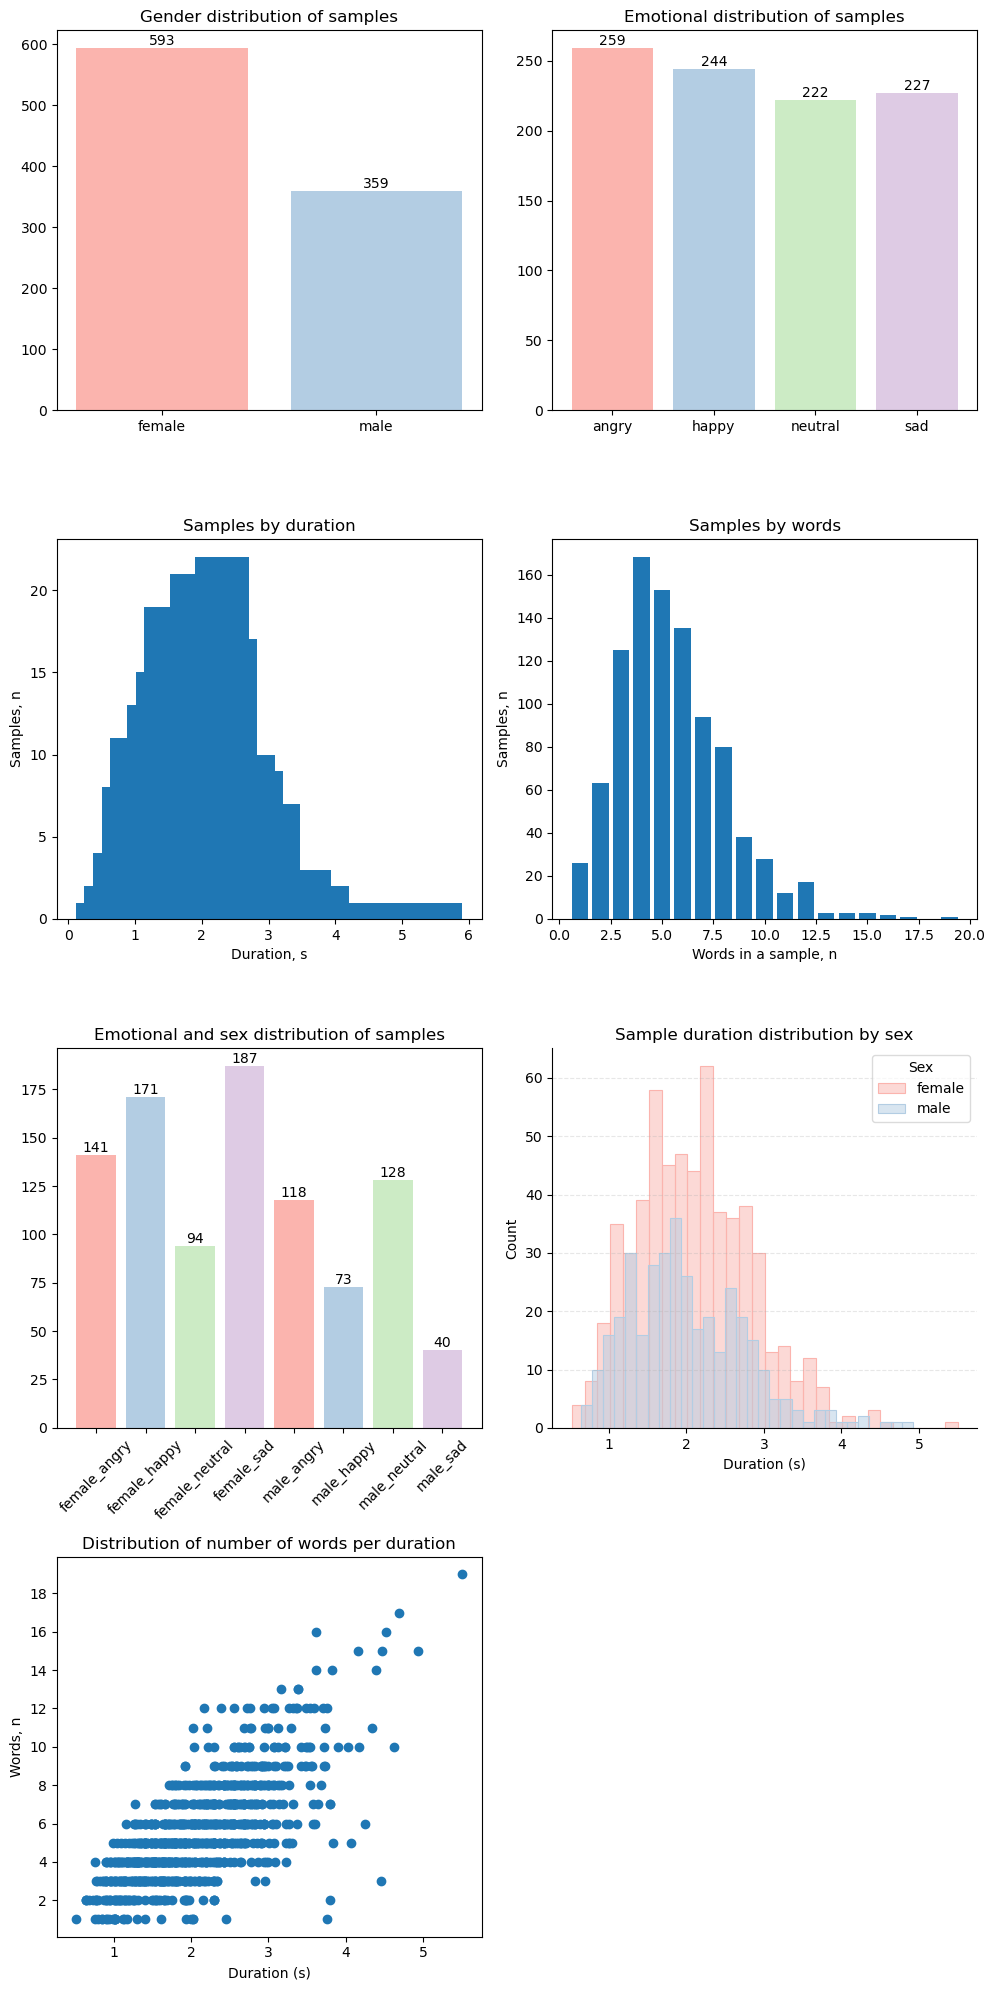

In [5]:
by_sex = df.groupby('sex').size().reset_index(name='counts')
by_emotion = df.groupby('emotion').size().reset_index(name='counts')
by_duration = df.groupby('duration_seconds').size().reset_index(name='counts')
by_words = df.groupby('nwords').size().reset_index(name='counts')

fig, ax = plt.subplots(4, 2, figsize=(10, 20))

colors = plt.colormaps['Pastel1'].colors[:len(by_sex)]
ax[0, 0].bar(by_sex['sex'], by_sex['counts'], color=colors)
ax[0, 0].set_title('Gender distribution of samples')
ax[0, 0].bar_label(ax[0, 0].containers[0], fmt='%d')

colors = plt.colormaps['Pastel1'].colors[:len(by_emotion)]
ax[0, 1].bar(by_emotion['emotion'], by_emotion['counts'], color=colors)
ax[0, 1].set_title('Emotional distribution of samples')
ax[0, 1].bar_label(ax[0, 1].containers[0], fmt='%d')

ax[1, 0].bar(by_duration['duration_seconds'], by_duration['counts'])
ax[1, 0].set_title('Samples by duration')
ax[1, 0].set_xlabel('Duration, s')
ax[1, 0].set_ylabel('Samples, n')

ax[1, 1].bar(by_words['nwords'], by_words['counts'])
ax[1, 1].set_title('Samples by words')
ax[1, 1].set_xlabel('Words in a sample, n')
ax[1, 1].set_ylabel('Samples, n')

by_sex_emotion = df.groupby(['sex', 'emotion']).size().reset_index(name='counts')
by_sex_emotion['index'] = by_sex_emotion['sex'].combine(by_sex_emotion['emotion'], lambda x, y: f"{x}_{y}")

colors = plt.colormaps['Pastel1'].colors[:len(set(by_sex_emotion))]
ax[2, 0].bar(by_sex_emotion['index'], by_sex_emotion['counts'], color=colors)
ax[2, 0].set_title('Emotional and sex distribution of samples')
ax[2, 0].bar_label(ax[2, 0].containers[0], fmt='%d')
ax[2, 0].tick_params(axis='x', rotation=45)

by_sex_duration = df.groupby('sex')['duration_seconds'].apply(list).to_dict()

sex_colors = {s: plt.colormaps['Pastel1'].colors[i] for i, s in enumerate(df['sex'].unique())}

for sex, durations in by_sex_duration.items():
    ax[2, 1].hist(
        durations,
        bins=30,
        label=sex,
        facecolor=(*sex_colors[sex][:3], 0.5),
        edgecolor=sex_colors[sex],
        linewidth=0.8,
    )

ax[2, 1].legend(title='Sex', framealpha=0.7)
ax[2, 1].set_title('Sample duration distribution by sex')
ax[2, 1].set_xlabel('Duration (s)')
ax[2, 1].set_ylabel('Count')
ax[2, 1].spines[['top', 'right']].set_visible(False)
ax[2, 1].grid(axis='y', alpha=0.3, linestyle='--')

words_per_second = df.copy()
words_per_second['wps'] = words_per_second['nwords'] / words_per_second['duration_seconds']
ax[3, 0].scatter(words_per_second['duration_seconds'], words_per_second['nwords'])
ax[3, 0].set_title('Distribution of number of words per duration')
ax[3, 0].set_xlabel('Duration (s)')
ax[3, 0].set_ylabel('Words, n')
ax[3, 0].yaxis.set_major_locator(MaxNLocator(integer=True))

ax[3, 1].set_visible(False)

fig.tight_layout()


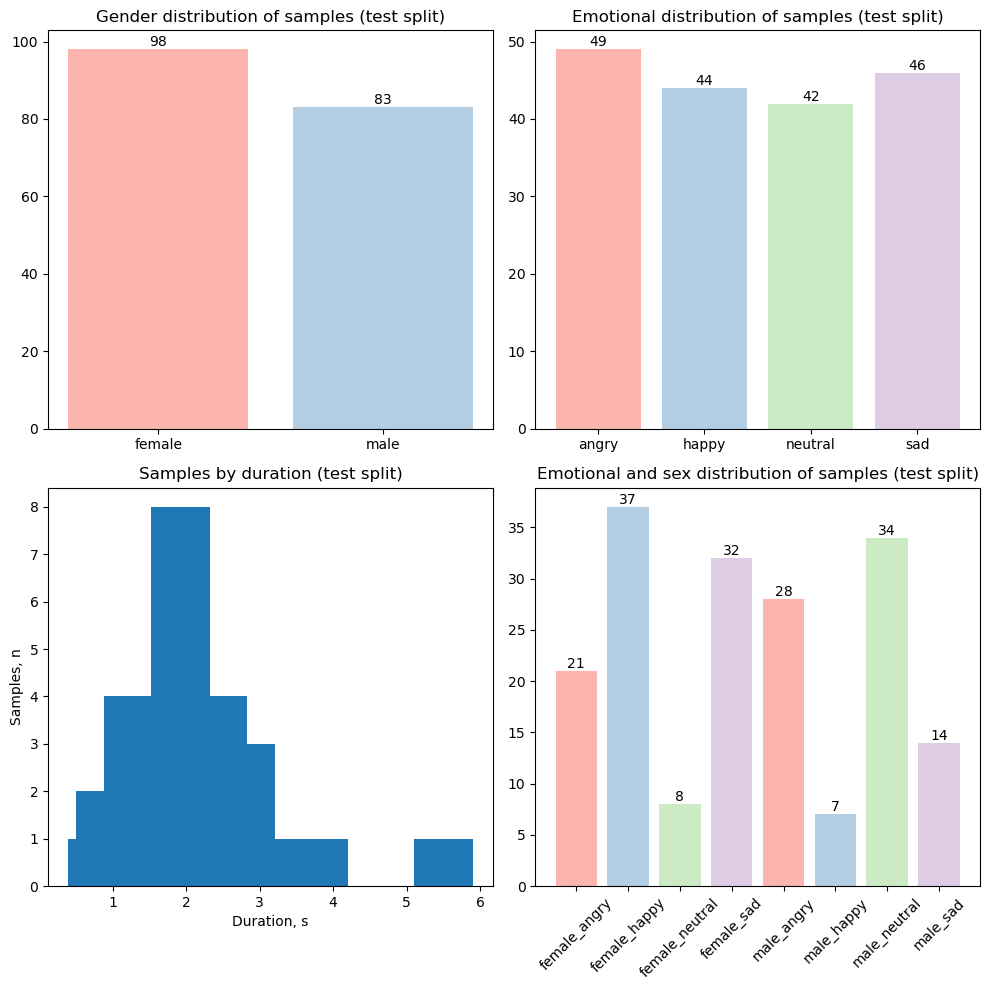

In [9]:
by_sex = df[df['split'] == 'test'].groupby('sex').size().reset_index(name='counts')
by_emotion = df[df['split'] == 'test'].groupby('emotion').size().reset_index(name='counts')
by_duration = df[df['split'] == 'test'].groupby('duration_seconds').size().reset_index(name='counts')

fig, ax = plt.subplots(2, 2, figsize=(10, 10))

colors = plt.colormaps['Pastel1'].colors[:len(by_sex)]
ax[0, 0].bar(by_sex['sex'], by_sex['counts'], color=colors)
ax[0, 0].set_title('Gender distribution of samples (test split)')
ax[0, 0].bar_label(ax[0, 0].containers[0], fmt='%d')

colors = plt.colormaps['Pastel1'].colors[:len(by_emotion)]
ax[0, 1].bar(by_emotion['emotion'], by_emotion['counts'], color=colors)
ax[0, 1].set_title('Emotional distribution of samples (test split)')
ax[0, 1].bar_label(ax[0, 1].containers[0], fmt='%d')

ax[1, 0].bar(by_duration['duration_seconds'], by_duration['counts'])
ax[1, 0].set_title('Samples by duration (test split)')
ax[1, 0].set_xlabel('Duration, s')
ax[1, 0].set_ylabel('Samples, n')

by_sex_emotion = df[df['split'] == 'test'].groupby(['sex', 'emotion']).size().reset_index(name='counts')
by_sex_emotion['index'] = by_sex_emotion['sex'].combine(by_sex_emotion['emotion'], lambda x, y: f"{x}_{y}")

colors = plt.colormaps['Pastel1'].colors[:len(set(by_sex_emotion))]
ax[1, 1].bar(by_sex_emotion['index'], by_sex_emotion['counts'], color=colors)
ax[1, 1].set_title('Emotional and sex distribution of samples (test split)')
ax[1, 1].bar_label(ax[1, 1].containers[0], fmt='%d')
ax[1, 1].tick_params(axis='x', rotation=45)

fig.tight_layout()


- Analyze the proposed target metric (UAR): discuss its strengths, weaknesses, and potential edge cases. TIP: Check metrics from the next subsection: “Compare with the Dataset Author's work”

- Suggest complementary metrics to capture other aspects of performance.

- Propose an alternative target metric, with justification.

### Validation:
- Use native train/test split. Design a separate validation split from the train set
- Explain your motivation for the chosen strategy and the importance of balancing gender and emotion classes within the splits.
- Discuss the challenges of achieving balanced class distributions in naturalistic emotion datasets.

### Spectral Features (MelSpec, MFCC):
- Extract handcrafted acoustic features (e.g., MFCCs, Pitch/F0, RMS energy, Zero-Crossing Rate).
- Explore classical machine learning classifiers or simple neural networks to establish a baseline for the 4-class emotion classification problem.
- Collect all relevant results:
- metrics (UAR, Accuracy, Macro F1)
- hard samples analysis (e.g., structural variations between neutral and sad, or angry and happy).
- Conclude whether acoustic features alone are adequate.
- Prepare an ablation study on the tested models

### Self-Supervised Approach (Data2Vec, Wave2Vec, …):
- Explore pre-trained self-supervised speech approaches, contrasting language-transfer models (e.g., wav2vec2-xls-r-300m-uk) with task-transfer models (e.g., emotion2vec+).
- Collect all relevant results:
- metrics (focusing on Unweighted Average Recall)
- hard samples analysis.
- Conclude whether the model is adequate.
- Prepare an ablation study on the tested models, exploring freezing depths (e.g., number of frozen transformer blocks), loss functions (Focal Loss vs. Cross-Entropy), and data augmentation techniques.

### Compare with the Dataset Author's work
- Explore the approach proposed by Olha Havryluk
- Explain how your approach differs from baseline and why is it better

### Final Report
- Prepare a comprehensive report including:
- data insights,
- feature engineering,
- tried algorithms and models,
- chosen hyperparameters,
- metrics,
- insights and conclusions.
- Reports may be prepared in LaTeX or Markdown (README.md).